In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('../data/preprocessed/crypto_data_proc.csv')
# raw = pd.read_csv('../data/raw/aggregated/crypto_data.csv')

In [38]:
def histo(df, col_name):
  mean = df[col_name].mean()
  std = df[col_name].std()
  lower = mean - 5*std
  upper = mean + 5*std

  sns.histplot(data=df, x=col_name, bins=100, kde=True)
  plt.xlim(lower, upper)
  plt.show()

## Check distribution

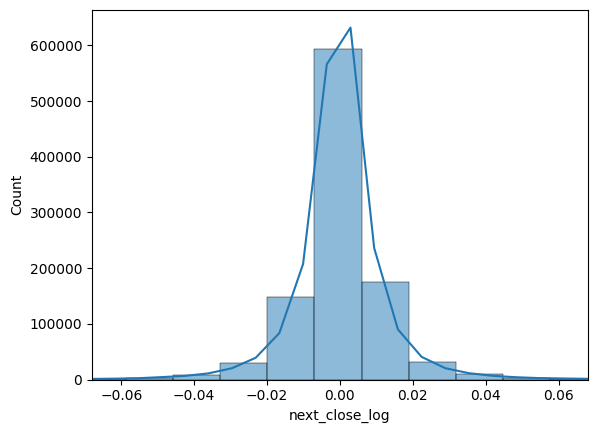

In [41]:
histo(df, 'next_close_log')

## Stationarity Check

Text(0.5, 1.0, 'Log Returns Over Time - Stationarity Check (CRV)')

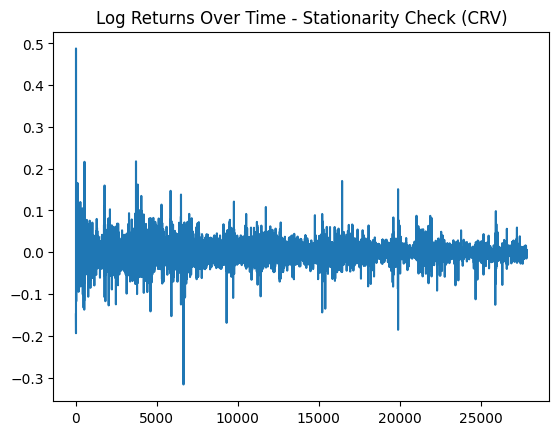

In [44]:
# Group by time windows and check if stats are stable
token = 'CRV'
df_sample = df[df['token'] == token]  # Pick one token
plt.plot(df_sample['time_idx'], df_sample['close_log'])
plt.title(f'Log Returns Over Time - Stationarity Check ({token})')

## Feature Correlation

Text(0.5, 1.0, 'Feature Correlation Matrix')

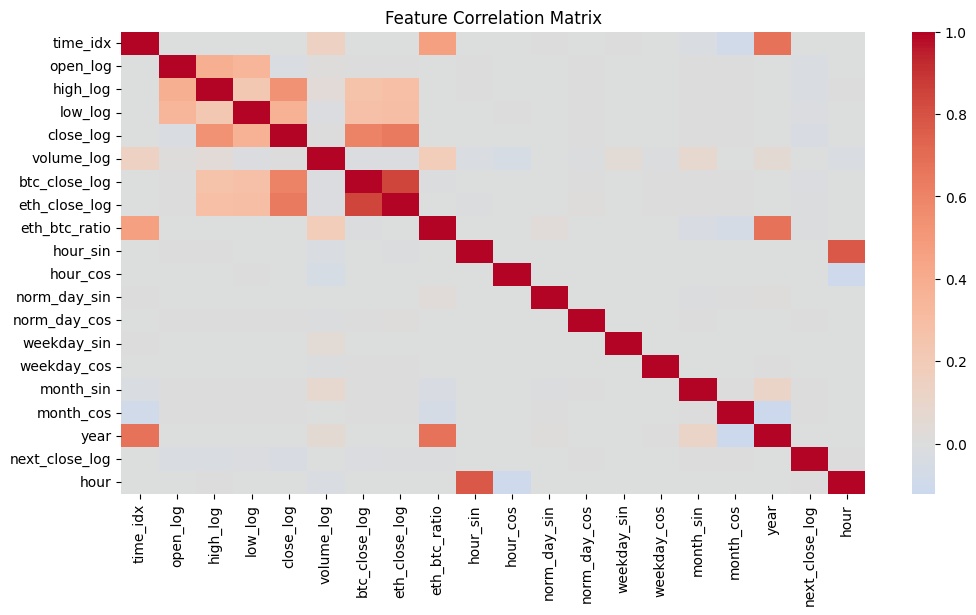

In [25]:
# See which features are correlated
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')

## Outliers

In [17]:
# How many extreme outliers?
Q1 = df['close_log'].quantile(0.25)
Q3 = df['close_log'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['close_log'] < Q1 - 3*IQR) | (df['close_log'] > Q3 + 3*IQR)]
print(f"Outliers: {len(outliers)} ({100*len(outliers)/len(df):.2f}%)")

Outliers: 25419 (2.51%)


## Volatility Analysis

Text(0.5, 1.0, 'Volatility by Token (Std Dev of Log Returns)')

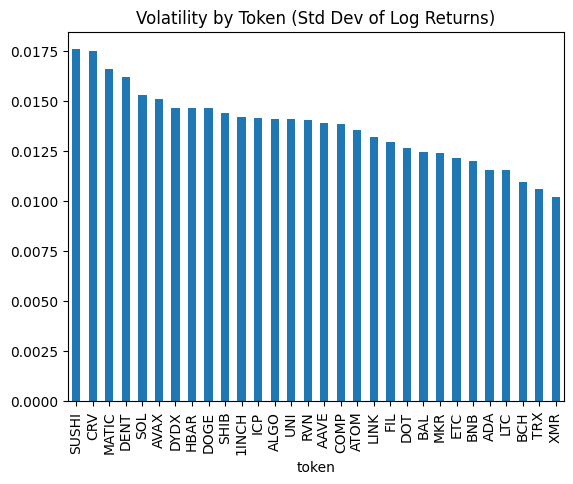

In [28]:
# Which tokens are most volatile?
volatility = df.groupby('token')['close_log'].std().sort_values(ascending=False)
volatility.plot(kind='bar')
plt.title('Volatility by Token (Std Dev of Log Returns)')

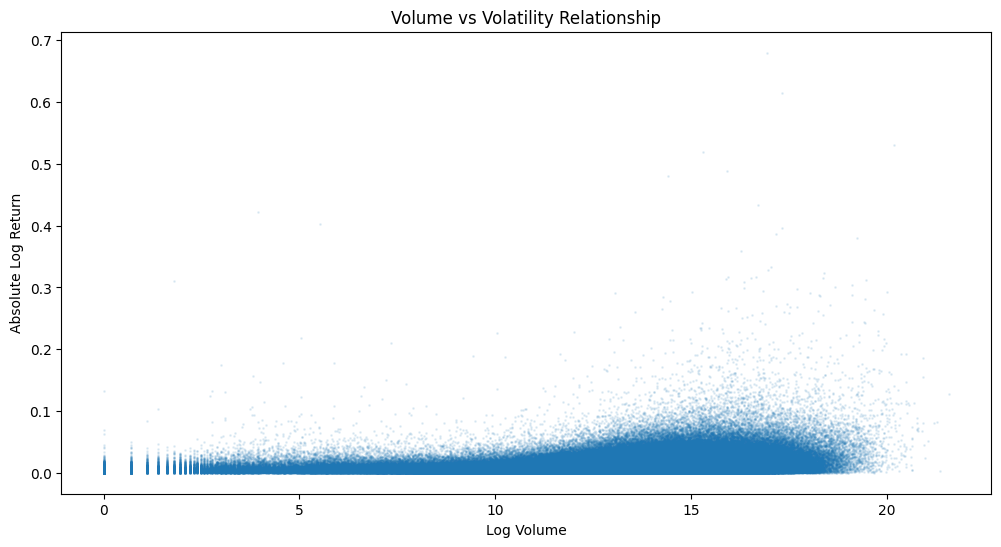

In [31]:
# Do high volume periods have different volatility?
df['abs_return'] = df['close_log'].abs()

plt.figure(figsize=(12, 6))
plt.scatter(df['volume_log'], df['abs_return'], alpha=0.1, s=1)
plt.xlabel('Log Volume')
plt.ylabel('Absolute Log Return')
plt.title('Volume vs Volatility Relationship')
plt.show()

/var/folders/zf/pd74vy996kg6l6dpbrpqm1jr0000gn/T/ipykernel_29510/3392336433.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  btc_corr = df.groupby('token').apply(


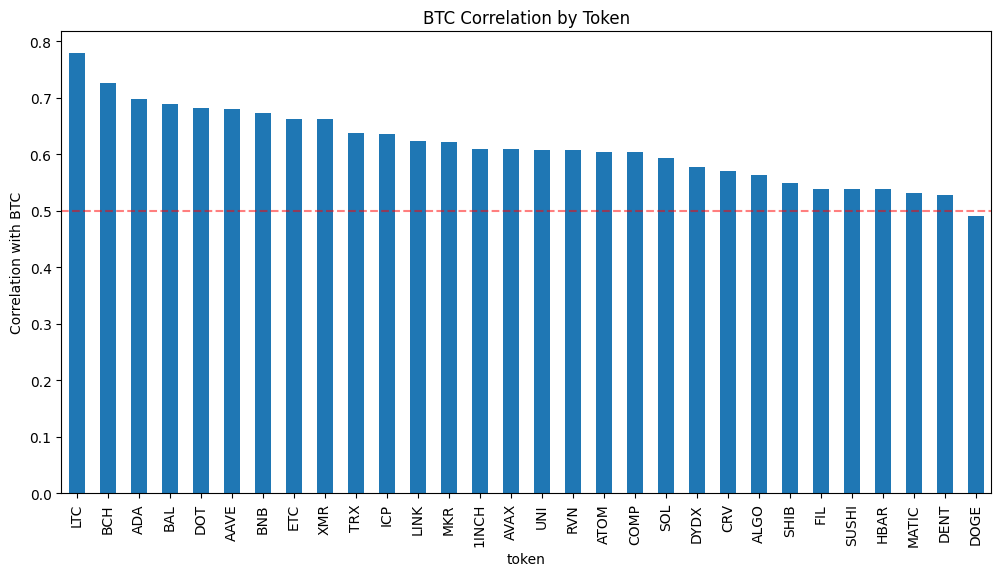

In [34]:
# Correlation by token - which tokens are most/least BTC-dependent?
btc_corr = df.groupby('token').apply(
    lambda x: x['close_log'].corr(x['btc_close_log'])
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
btc_corr.plot(kind='bar')
plt.title('BTC Correlation by Token')
plt.ylabel('Correlation with BTC')
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.show()

Based on the visuals it looks like the preprocessed data looks good! 

We have normal distributions, no extreme unexpected correlations, stationarity even on the most 
volatile tokens, and strong hints at a btc/eth price and alt coin price correlation. 

This correlation could lend invaluable insights for our predictions.